In [1]:
import os
import sys

# Add your module's directory (absolute path or relative path)
module_path = os.path.abspath(os.path.join('../src')) 
if module_path not in sys.path:
    sys.path.insert(0, module_path)


In [2]:
from policy_metrics import probability_success, mean_return, play_episode
from display import print_policy, print_transitions, print_state_value_function

from multi_armed_bandit import MultiArmedBandit
from models import Environment
from dp import policy_improvement, policy_evaluation, policy_iteration
import random
import numpy as np
from bandit_strategy import get_bandit_results, list_strategies

from dataclasses import dataclass
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from typing import Sequence

In [3]:
# Ten multi armed bandit with random probabilities

mab = MultiArmedBandit(n_arms=10)
mab.true_values

[0.15, 0.08, 0.8, 0.86, 0.62, 0.09, 0.96, 0.13, 0.89, 0.65]

In [4]:
print(list_strategies())

['greedy', 'random', 'epsilon_greedy', 'decay_epsilon_greedy', 'optimistic', 'softmax', 'ucb', 'thompson']


In [5]:
results = []

results.append(get_bandit_results(mab, "epsilon_greedy", n_episodes=5000, epsilon=0.05))
results.append(get_bandit_results(mab, "ucb", n_episodes=5000, c=3.0))
results.append(get_bandit_results(mab, "thompson", n_episodes=2000))
results.append(get_bandit_results(mab, "optimistic", q_init=2.0, n_init=5))
results.append(get_bandit_results(mab, "softmax", init_temp=1.0, decay=0.1, min_temp=0.01))
results.append(get_bandit_results(mab, "decay_epsilon_greedy", init_epsilon=1.0, decay=0.5, min_epsilon=0.01))
results.append(get_bandit_results(mab, "greedy"))
results.append(get_bandit_results(mab, "random"))

In [6]:
@dataclass
class BanditEpisodicResults:
    returns: np.ndarray
    Q_e: np.ndarray
    actions: np.ndarray
    episodes: int
    title: str

In [16]:

_STRAT_COLORS = plt.get_cmap("tab10").colors     # one per strategy
_ARM_COLORS   = plt.get_cmap("tab20").colors     # one per arm
_LINESTYLES   = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]


def _as_list(results):
    if isinstance(results, BanditEpisodicResults):
        return [results]
    return list(results)


def _strategy_labels(results, labels):
    n = len(results)
    if labels is not None:
        if len(labels) != n:
            raise ValueError(f"{len(labels)} labels for {n} results")
        return list(labels)
    return [getattr(r, "title", "") or f"strategy {i}" for i, r in enumerate(results)]

def plot_bandit_comparison(results: Sequence[BanditEpisodicResults] | BanditEpisodicResults,
                           labels: Sequence[str] | None = None,
                           arm_labels: Sequence[str] | None = None,
                           title: str = "Bandit strategies compared",
                           rolling_window: int = 100,
                           show_raw_rewards: bool = True,
                           true_values: Sequence[float] | None = None,
                           annotate_bars: bool = True,
                           figsize=(12, 10),
                           save_path: str | None = None):
    """Compare bandit strategies in a single figure.

    results      : one BanditEpisodicResults or a list of them (per strategy)
    labels       : strategy names; defaults to each result's `title`
    arm_labels   : display names for the arms, e.g. ['LEFT', 'RIGHT']
    true_values  : expected reward per arm -> dashed reference lines in Q panel
    annotate_bars: print the pull fraction on top of each bar (small problems
                   only; automatically disabled when there are many bars)

    Note: ONE figure-level legend, placed at the very bottom, lists both the
    arms (line color) and the strategies (line style).
    """
    results = _as_list(results)
    n = len(results)
    names = _strategy_labels(results, labels)

    n_arms = results[0].Q_e.shape[1]
    if any(r.Q_e.shape[1] != n_arms for r in results):
        raise ValueError("all results must have the same number of arms")
    if arm_labels is None:
        arm_labels = [f"arm {i}" for i in range(n_arms)]
    if len(arm_labels) != n_arms:
        raise ValueError(f"{len(arm_labels)} arm_labels for {n_arms} arms")

    strat_colors = [_STRAT_COLORS[i % 10] for i in range(n)]
    arm_colors   = [_ARM_COLORS[a % 20] for a in range(n_arms)]
    linestyles   = [_LINESTYLES[i % len(_LINESTYLES)] for i in range(n)]

    # NOTE: do NOT share x across all three panels.
    # Only Q (panel 1) and Rewards (panel 2) share the episodes axis;
    # the Actions panel keeps its own arm-index axis.
    fig, axes = plt.subplots(3, 1, figsize=figsize,
                             sharex=False,
                             gridspec_kw={"height_ratios": [1, 1.2, 1]})
    axes[2].sharex(axes[1])                       # link episodes axis
    plt.setp(axes[1].get_xticklabels(), visible=False)  # labels only on bottom
    fig.suptitle(title, fontsize=14)

    # ==================== 1) ACTIONS: grouped bar chart =====================
    ax = axes[0]
    x = np.arange(n_arms)
    bar_width = 0.8 / n
    for i, r in enumerate(results):
        pulls = np.bincount(r.actions.astype(int), minlength=n_arms) / r.episodes
        offset = (i - (n - 1) / 2) * bar_width
        ax.bar(x + offset, pulls, bar_width,
               label=names[i], color=strat_colors[i],
               edgecolor=strat_colors[i], linewidth=1.0, alpha=0.9)

        if annotate_bars and n * n_arms <= 24:    # skip when too crowded
            for xi, pv in zip(x + offset, pulls):
                if pv > 0.02:                     # don't clutter tiny bars
                    ax.text(xi, pv + 0.02, f"{pv:.2f}", ha="center",
                            va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(arm_labels)
    ax.set_xlim(-0.6, n_arms - 0.4)               # full-width bars, own axis
    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.set_ylabel("fraction of pulls")
    ax.set_title("Actions pulled per strategy (fraction of episodes)")

    # ==================== 2) Q ESTIMATES: lines ============================
    ax = axes[1]
    for i, r in enumerate(results):
        eps = np.arange(1, r.episodes + 1)
        for a in range(n_arms):
            ax.plot(eps, r.Q_e[:, a], color=arm_colors[a],
                    linestyle=linestyles[i], linewidth=1.4, alpha=0.9)

    if true_values is not None:
        for a, tv in enumerate(true_values):
            if tv is not None:
                ax.axhline(tv, color=arm_colors[a], linestyle=":",
                           linewidth=1.0, alpha=0.5)

    ax.set_ylabel("Q estimate")
    ax.set_title("Running action-value estimates  (color = arm, linestyle = strategy)")

    # ==================== 3) REWARDS: rolling mean ==========================
    ax = axes[2]
    for i, r in enumerate(results):
        eps = np.arange(1, r.episodes + 1)
        if show_raw_rewards:
            ax.plot(eps, r.returns, color=strat_colors[i], alpha=0.12,
                    linewidth=0.7, label="_nolegend_")
        if rolling_window and r.episodes >= rolling_window:
            kernel = np.ones(rolling_window) / rolling_window
            mov = np.convolve(r.returns, kernel, mode="valid")
            ax.plot(eps[rolling_window - 1:], mov, color=strat_colors[i],
                    linewidth=2.0, label=names[i])

    ax.set_xlabel("episodes")
    ax.set_ylabel("reward")
    ax.set_title("Rewards (faint = raw, thick = rolling mean)")

    # ========== ONE figure-level legend at the very bottom =================
    # Arms  -> colored solid lines (matches Q-panel color coding).
    # Strat -> gray lines with linestyle (matches Q-panel linestyle coding).
    arm_handles = [Line2D([0], [0], color=arm_colors[a], label=arm_labels[a])
                   for a in range(n_arms)]
    strat_handles = [Line2D([0], [0], color="gray", linestyle=linestyles[i],
                            label=names[i]) for i in range(n)]

    total_entries = n_arms + n
    fig.legend(handles=arm_handles + strat_handles,
               ncol=(total_entries + 1) // 2,     # 18 entries -> 2 rows of 9
               loc="lower center",
               bbox_to_anchor=(0.5, 0.0),
               fontsize=8,
               frameon=True,
               edgecolor="0.6",
               title="Arm (color)  \u00b7  Strategy (linestyle)",
               title_fontsize=9)

    # Panels keep full width & natural height; bottom ~10% is for the legend.
    fig.tight_layout(rect=(0, 0.10, 1, 0.96))
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig, axes


In [17]:
mab.true_values

[0.15, 0.08, 0.8, 0.86, 0.62, 0.09, 0.96, 0.13, 0.89, 0.65]

(<Figure size 1200x1000 with 3 Axes>,
 array([<Axes: title={'center': 'Actions pulled per strategy (fraction of episodes)'}, ylabel='fraction of pulls'>,
        <Axes: title={'center': 'Running action-value estimates  (color = arm, linestyle = strategy)'}, ylabel='Q estimate'>,
        <Axes: title={'center': 'Rewards (faint = raw, thick = rolling mean)'}, xlabel='episodes', ylabel='reward'>],
       dtype=object))

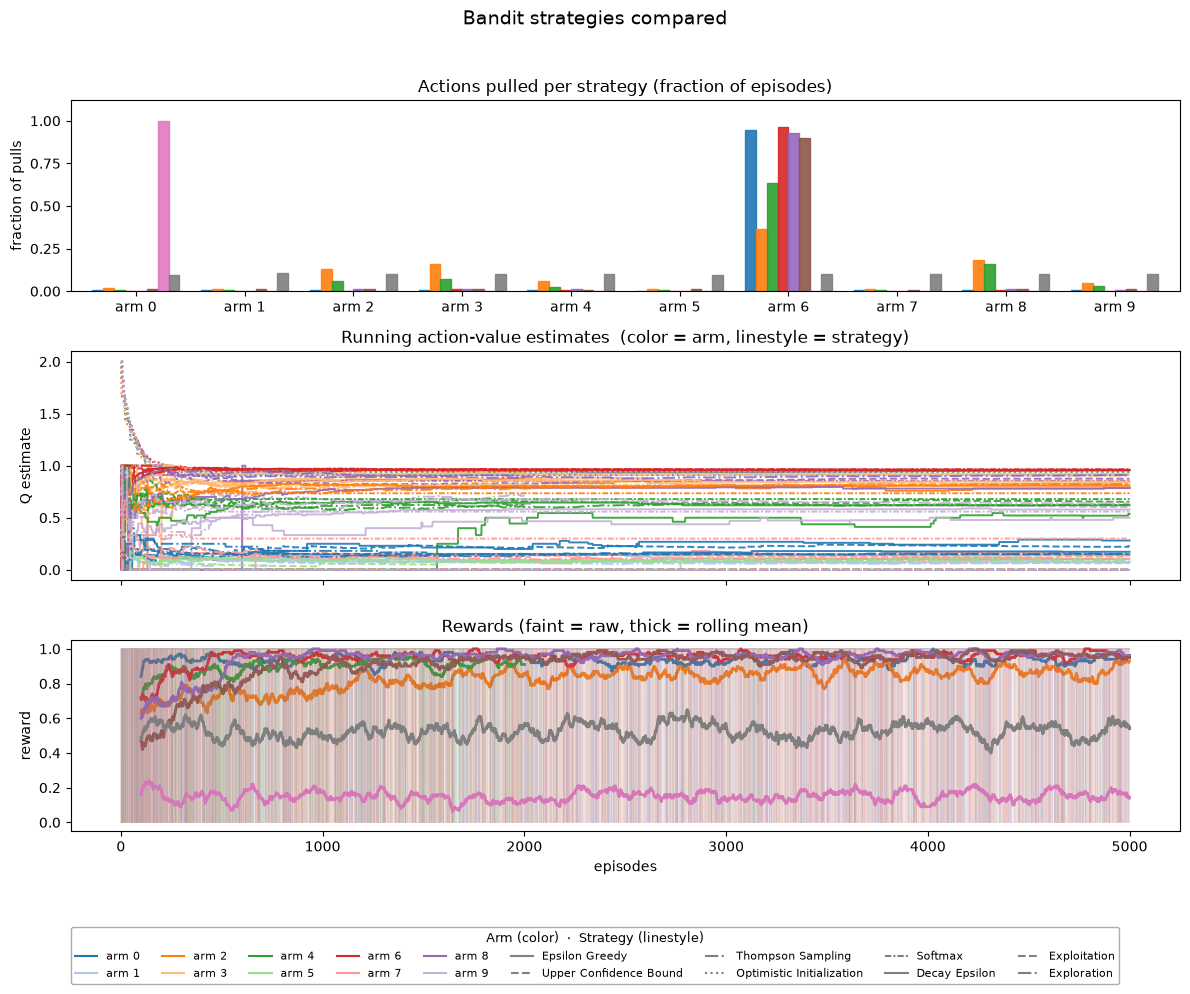

In [18]:
plot_bandit_comparison(results)